In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

In [2]:
data = load_digits()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Dataset shape: (1797, 64)
Number of classes: 10


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
model_original = LogisticRegression(max_iter=1000)

start = time.time()

model_original.fit(X_train_scaled, y_train)

y_pred_original = model_original.predict(X_test_scaled)

original_time = time.time() - start

original_accuracy = accuracy_score(y_test, y_pred_original)

print("Original Features:", X_train_scaled.shape[1])
print("Original Accuracy:", original_accuracy)
print("Original Training Time:", original_time)

Original Features: 64
Original Accuracy: 0.9722222222222222
Original Training Time: 0.0980844497680664


In [6]:
pca = PCA(n_components=20)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Features after PCA:", X_train_pca.shape[1])

Features after PCA: 20


In [7]:
model_pca = LogisticRegression(max_iter=1000)

start = time.time()

model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)

pca_time = time.time() - start

pca_accuracy = accuracy_score(y_test, y_pred_pca)

print("PCA Accuracy:", pca_accuracy)
print("PCA Training Time:", pca_time)

PCA Accuracy: 0.9416666666666667
PCA Training Time: 0.05046892166137695


In [8]:
lda = LinearDiscriminantAnalysis(n_components=9)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print("Features after LDA:", X_train_lda.shape[1])

Features after LDA: 9


In [9]:
model_lda = LogisticRegression(max_iter=1000)

start = time.time()

model_lda.fit(X_train_lda, y_train)

y_pred_lda = model_lda.predict(X_test_lda)

lda_time = time.time() - start

lda_accuracy = accuracy_score(y_test, y_pred_lda)

print("LDA Accuracy:", lda_accuracy)
print("LDA Training Time:", lda_time)

LDA Accuracy: 0.9555555555555556
LDA Training Time: 0.05352377891540527


In [10]:
print("\n----- Performance Comparison -----")

print("Original Features : 64")
print("Original Accuracy :", original_accuracy)
print("Original Time     :", original_time)

print("\nPCA Features       : 20")
print("PCA Accuracy       :", pca_accuracy)
print("PCA Time           :", pca_time)

print("\nLDA Features       : 9")
print("LDA Accuracy       :", lda_accuracy)
print("LDA Time           :", lda_time)


----- Performance Comparison -----
Original Features : 64
Original Accuracy : 0.9722222222222222
Original Time     : 0.0980844497680664

PCA Features       : 20
PCA Accuracy       : 0.9416666666666667
PCA Time           : 0.05046892166137695

LDA Features       : 9
LDA Accuracy       : 0.9555555555555556
LDA Time           : 0.05352377891540527


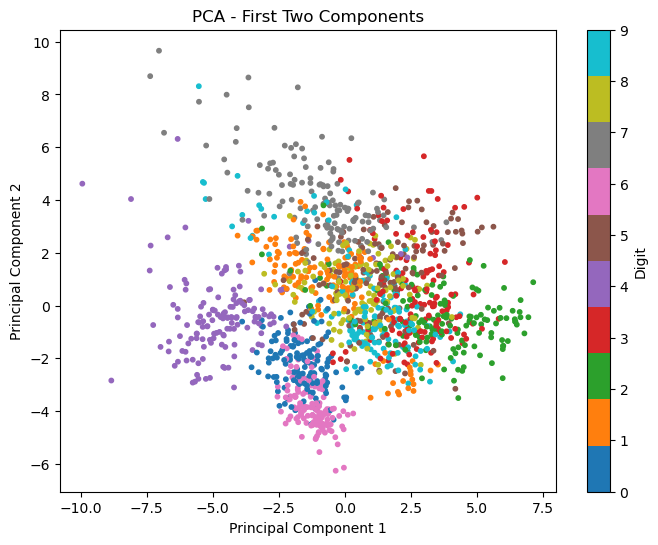

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap="tab10",
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - First Two Components")
plt.colorbar(label="Digit")
plt.show()

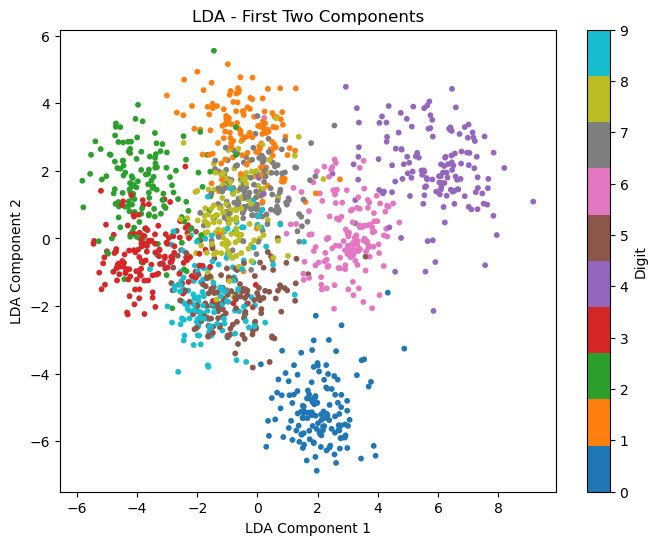

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_lda[:, 0],
    X_train_lda[:, 1],
    c=y_train,
    cmap="tab10",
    s=10
)

plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA - First Two Components")
plt.colorbar(label="Digit")
plt.show()